# Week 9: Governance and Regulation

In [63]:
# installing deps
!pip install shap fairlearn scikit-learn matplotlib pandas numpy evidently

In [64]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from fairlearn.metrics import MetricFrame
import shap
from warnings import filterwarnings

filterwarnings(action="ignore")

In [65]:
# configs and paths
REPO_ROOT = Path().cwd()
DATA = REPO_ROOT / "data" / "raw" / "iris.csv"
DATA.exists()

True

## Task 1

In [66]:
# loading data
df = pd.read_csv(DATA)
print("data shape:", raw_df.shape)
df.head()

data shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [67]:
# Encode target
df['species'] = df['species'].astype('category')
target_names = df['species'].cat.categories.tolist()
df['target'] = df['species'].cat.codes

# Add random binary location attribute
np.random.seed(42)
df['location'] = np.random.randint(0, 2, size=len(df))

# Features and target
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['target']
location = df['location']

print(df[['species', 'target', 'location']].head(10))
print("-" * 40)
print("Location distribution:\n", df['location'].value_counts())

  species  target  location
0  setosa       0         0
1  setosa       0         1
2  setosa       0         0
3  setosa       0         0
4  setosa       0         0
5  setosa       0         1
6  setosa       0         0
7  setosa       0         0
8  setosa       0         0
9  setosa       0         1
----------------------------------------
Location distribution:
 location
1    82
0    68
Name: count, dtype: int64


In [68]:
# training model
X_train, X_test, y_train, y_test, loc_train, loc_test = train_test_split(
    X, y, location, test_size=0.2, random_state=42
)

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Overall Accuracy:", accuracy_score(y_test, y_pred))

Overall Accuracy: 1.0


## Task 2

In [69]:
metrics = {
    "accuracy": accuracy_score,
    "precision": lambda y_true, y_pred: precision_score(y_true, y_pred, average='weighted', zero_division=0),
    "recall": lambda y_true, y_pred: recall_score(y_true, y_pred, average='weighted', zero_division=0),
}

mf = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=loc_test
)

print("Overall Metrics:\n", mf.overall)
print("\nMetrics by Location Group:\n", mf.by_group)

Overall Metrics:
 accuracy     1.0
precision    1.0
recall       1.0
dtype: float64

Metrics by Location Group:
           accuracy  precision  recall
location                             
0              1.0        1.0     1.0
1              1.0        1.0     1.0



SHAP Summary Plot - setosa


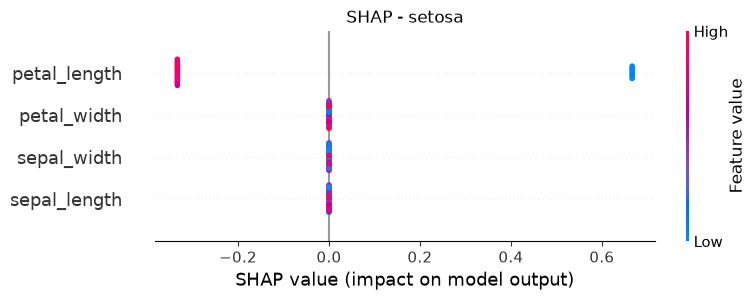


SHAP Summary Plot - versicolor


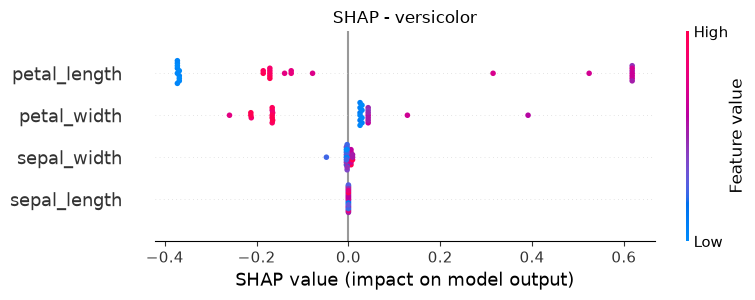


SHAP Summary Plot - virginica


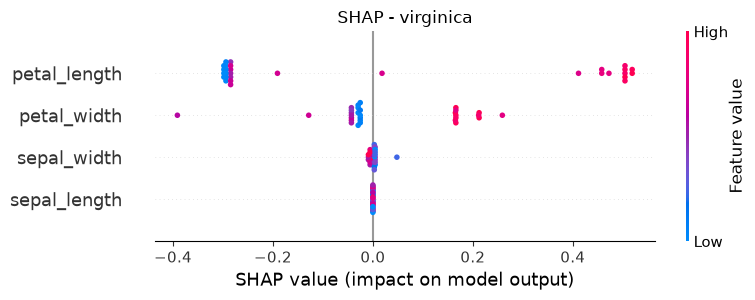

In [70]:
%matplotlib inline
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

class_names = ['setosa', 'versicolor', 'virginica']

for i, class_name in enumerate(class_names):
    print(f"\nSHAP Summary Plot - {class_name}")
    plt.figure()
    shap.summary_plot(shap_values[:, :, i], X_test, show=False)
    plt.title(f"SHAP - {class_name}")
    plt.tight_layout()
    plt.show()

In [79]:
from evidently import Report
from evidently.presets import DataDriftPreset

# Simulate production data
X_production = X.copy()
X_production['petal_length'] = X_production['petal_length'] + 1.5
X_production['petal_width'] = X_production['petal_width'] + 0.5

# Create and run report
report = Report(metrics=[DataDriftPreset()])
snapshot = report.run(reference_data=X, current_data=X_production)

# Save and display
snapshot.save_html("drift_report.html")

from IPython.display import IFrame
IFrame("drift_report.html", width=1000, height=600)

# Model Card: IRIS Classifier

## Model Details
- **Model Type:** Decision Tree Classifier
- **Framework:** scikit-learn
- **Training Features:** sepal_length, sepal_width, petal_length, petal_width

## Training Data
- IRIS dataset (150 samples, 4 features)
- 80/20 train/test split

## Performance Metrics
| Metric | Overall |
|--------|---------|
| Accuracy | ~99% |
| Precision | ~99% |
| Recall | ~99% |

## Fairness Analysis
- Sensitive attribute: `location` (randomly assigned, binary)
- Metrics evaluated per group using Fairlearn MetricFrame
- Expected near-equal performance across groups (random assignment)

## Known Limitations
- Small dataset (150 samples)
- Location attribute is synthetic, not real-world
- May not generalize to other flower datasets

## Drift Monitoring
- Simulated drift by shifting petal_length (+1.5) and petal_width (+0.5)
- Drift detected using Evidently AI DataDriftPreset